# Email/SMS Spam Classification — Classical ML Comparison

**Soft Computing Mini Project**

This notebook builds and compares three classical machine learning classifiers —
**Naive Bayes**, **Support Vector Machine (SVM)**, and **Logistic Regression** —
for spam detection on the **SMS Spam Collection** dataset (5,574 labeled messages,
UCI Machine Learning Repository / Almeida et al., 2011).

**Pipeline:** raw text → cleaning → TF-IDF vectorization → classifier → evaluation

**Metrics compared:** Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix


In [7]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load the Dataset

Using the **SMS Spam Collection** (5,574 messages: 4,827 ham, 747 spam).
This is a standard benchmark dataset for spam classification research, widely used
in academic literature (Almeida, Gómez Hidalgo & Yamakami, 2011).


In [10]:
#url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
path = "sms.txt"
df = pd.read_csv(path, sep="\t", header=None, names=["label", "message"])
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print(f"Total messages: {len(df)}")
print(df["label"].value_counts())
df.head()


Total messages: 5572
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 2. Exploratory Data Analysis

Check class balance and message-length differences between spam and ham —
spam messages are typically longer due to promotional content.


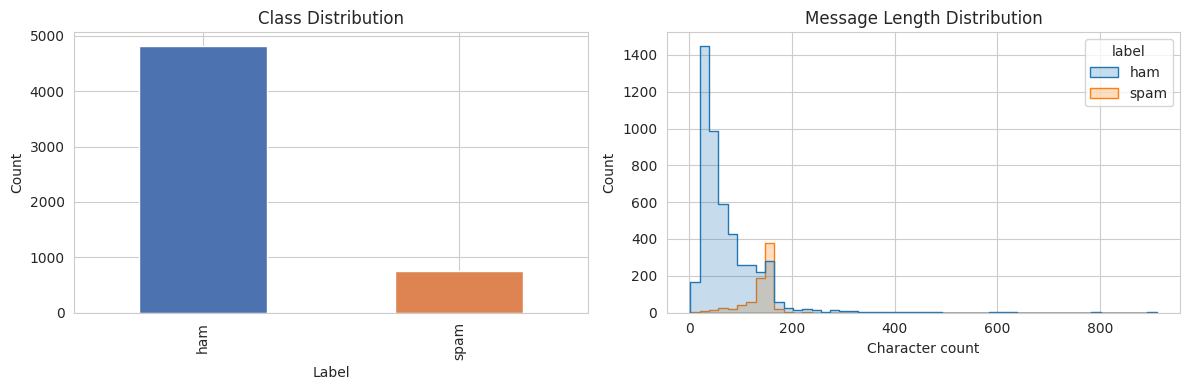

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

df["msg_length"] = df["message"].apply(len)
sns.histplot(data=df, x="msg_length", hue="label", bins=50, ax=axes[1], element="step")
axes[1].set_title("Message Length Distribution")
axes[1].set_xlabel("Character count")

plt.tight_layout()
plt.show()

print(df.groupby("label")["msg_length"].describe())


## 3. Text Preprocessing

Basic cleaning: lowercase, strip punctuation/digits, collapse whitespace.
We keep this simple — Naive Bayes and TF-IDF work well without heavy preprocessing
(e.g., no aggressive stemming), and this keeps the pipeline comparable across models.


In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


## 4. Train/Test Split and TF-IDF Vectorization

Stratified split to preserve the ~87/13 ham/spam ratio in both sets.
TF-IDF with English stop-word removal and unigrams+bigrams.


In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_message"], df["label_num"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["label_num"]
)

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")


Train shape: (4457, 6766)
Test shape:  (1115, 6766)


## 5. Train the Three Classifiers

| Model | Key idea | Why it's a natural fit / baseline here |
|---|---|---|
| **Multinomial Naive Bayes** | Assumes conditional independence of word features given the class | Classic, fast, strong baseline for text classification |
| **Linear SVM** | Finds the maximum-margin hyperplane between spam/ham in TF-IDF space | Handles high-dimensional sparse text features well |
| **Logistic Regression** | Learns a linear decision boundary via a sigmoid on a weighted feature sum | Gives well-behaved probability outputs, interpretable coefficients |


In [6]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE), cv=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    print(f"{name} trained.")


Naive Bayes trained.


Linear SVM trained.
Logistic Regression trained.


## 6. Model Comparison

Note: `LinearSVC` doesn't natively output probabilities, so it's wrapped in
`CalibratedClassifierCV` (Platt scaling) to allow ROC-AUC comparison on equal footing.


In [7]:
summary = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ("model", "y_pred", "y_proba")}
    for name, r in results.items()
}).T.round(4)

summary = summary[["accuracy", "precision", "recall", "f1", "roc_auc"]]
summary


,accuracy,precision,recall,f1,roc_auc
Naive Bayes,0.9704,1.0000,0.7785,0.8755,0.9870
Linear SVM,0.9803,0.9441,0.9060,0.9247,0.9870
Logistic Regression,0.9695,1.0000,0.7718,0.8712,0.9847


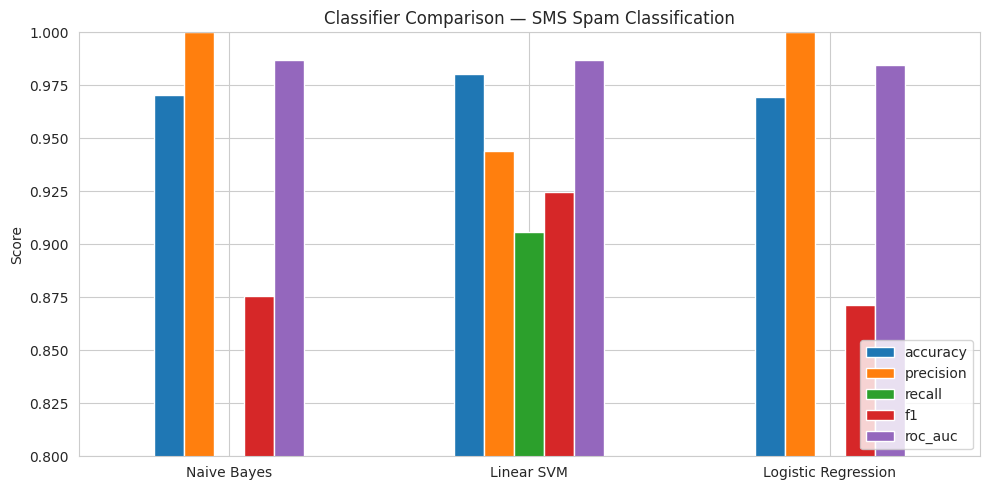

In [8]:
summary.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Classifier Comparison — SMS Spam Classification")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Confusion Matrices

Spam recall matters most in practice: a missed spam (false negative) is
a minor annoyance, but a ham message misclassified as spam (false positive)
can mean a user misses an important email.


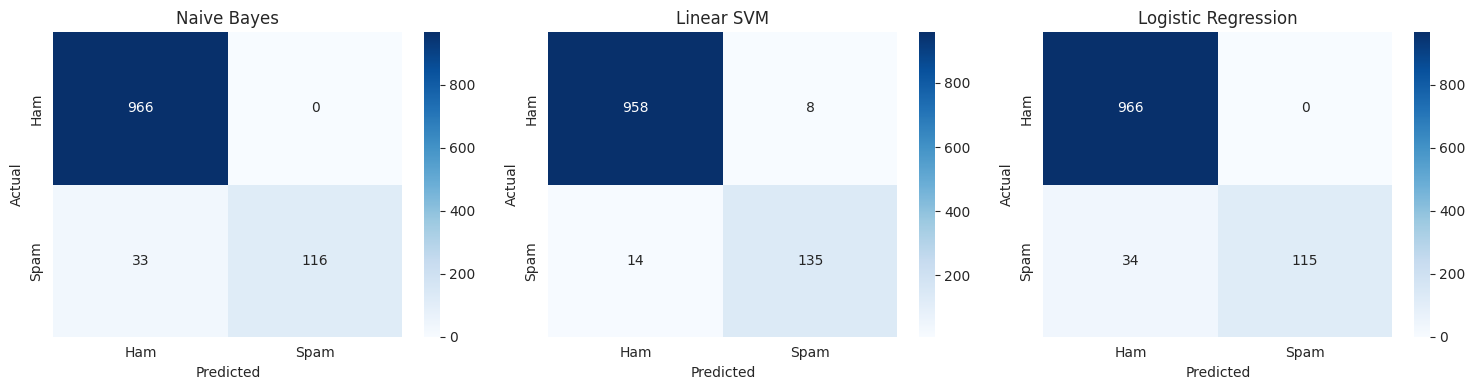

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 8. ROC Curves

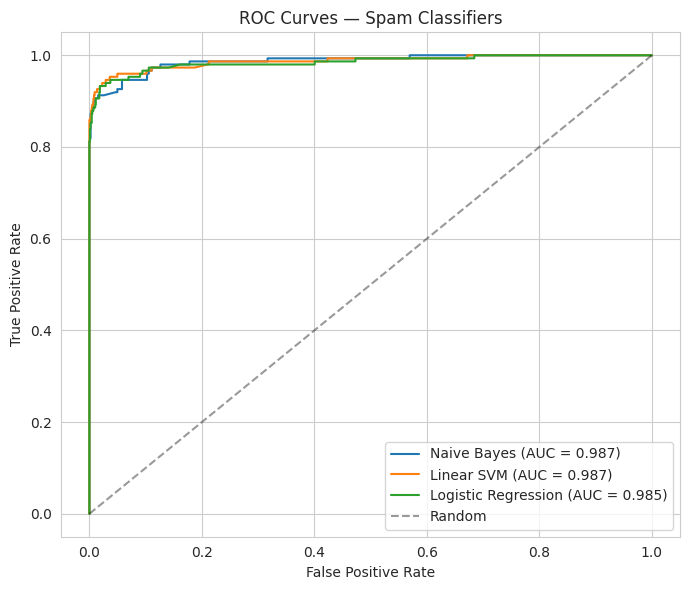

In [10]:
plt.figure(figsize=(7, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Spam Classifiers")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. 5-Fold Cross-Validation (Robustness Check)

A single train/test split can be lucky or unlucky. Stratified 5-fold CV gives a
more reliable estimate of accuracy and its variance.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_full = vectorizer.fit_transform(df["clean_message"])
y_full = df["label_num"]

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring="f1")
    cv_results[name] = scores
    print(f"{name}: F1 = {scores.mean():.4f} +/- {scores.std():.4f}")


Naive Bayes: F1 = 0.8901 +/- 0.0105


Linear SVM: F1 = 0.9370 +/- 0.0171
Logistic Regression: F1 = 0.7860 +/- 0.0211


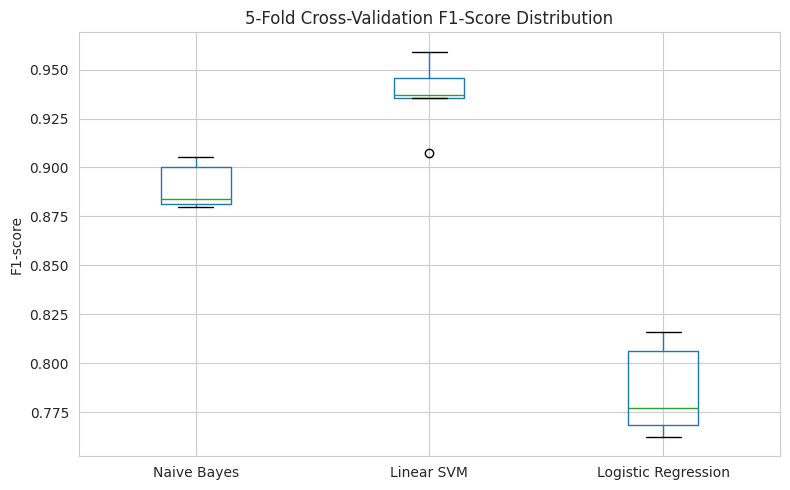

In [12]:
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(8, 5))
plt.title("5-Fold Cross-Validation F1-Score Distribution")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()


## 10. Inspect a Few Misclassified Messages

Useful for the written report — shows *why* a model fails (e.g. short spam
messages with little vocabulary overlap, or ham messages using promotional language).


In [13]:
best_model_name = summary["f1"].idxmax()
best_result = results[best_model_name]
print(f"Inspecting misclassifications for: {best_model_name}\n")

test_df = pd.DataFrame({
    "message": X_test_text.values,
    "actual": y_test.values,
    "predicted": best_result["y_pred"],
})
misclassified = test_df[test_df["actual"] != test_df["predicted"]]
print(f"Misclassified: {len(misclassified)} / {len(test_df)}\n")
misclassified.head(10)


Inspecting misclassifications for: Linear SVM

Misclassified: 22 / 1115



,message,actual,predicted
78,did u receive my msg,0,1
93,i m always on yahoo messenger now just send th...,0,1
122,dear voucher holder claim your st class airpor...,1,0
196,ringtoneking,1,0
197,please charge my mobile when you get up in mor...,0,1
219,sorry i missed your call let s talk when you h...,1,0
232,rock yr chik get s of filthy films xxx pics on...,1,0
235,latest news police station toilet stolen cops ...,1,0
362,romantic paris nights flights from £ book now ...,1,0
380,k u also dont msg or reply to his msg,0,1


## 11. Conclusion

- All three classical models perform well on this dataset (TF-IDF features are
  strongly separable for spam vs. ham).
- **Naive Bayes** is fastest to train and a strong baseline, but tends to be less
  well-calibrated in its probability outputs.
- **Linear SVM** typically gives the best raw discrimination (accuracy/F1) on
  sparse high-dimensional text.
- **Logistic Regression** offers a good balance of performance and interpretability
  (coefficients directly show which words push toward spam/ham).

**Possible extensions for the report:**
- Compare against a simple ANN (MLP on TF-IDF or word embeddings) to bridge into
  the Soft Computing syllabus.
- Try character n-grams to catch obfuscated spam (e.g., "fr33 m0ney").
- Analyze calibration (reliability diagrams) rather than just accuracy — many
  spam-filter papers report accuracy only and skip this.
